

## What this notebook does

| Section | Cells | Task |
|---------|-------|------|
| A | 1–2 | Setup & load data |
| B | 3–7 | Feature Engineering (fill nulls → encode → engineer → text → combine) |
| C | 8–11 | Model Training — XGBoost (emotional state + intensity) |
| D | 12–13 | Uncertainty scoring + Decision Engine |
| E | 14–15 | Generate predictions.csv + save everything |

---



## Cell 1 — Install & Import

In [1]:
import subprocess, sys
for pkg in ['pandas','numpy','scikit-learn','xgboost','matplotlib','seaborn','joblib','textblob']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print(' Libraries ready')

 Libraries ready


In [2]:
import os, re, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter

# sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, mean_absolute_error
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

# XGBoost
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/artifacts', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)
print(' Imports done')

 Imports done


## Cell 2 — Load Data

In [3]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(f'Train : {train.shape[0]} rows × {train.shape[1]} cols')
print(f'Test  : {test.shape[0]} rows × {test.shape[1]} cols')
print()
print('Train columns:', train.columns.tolist())
print()
train.head(3)

Train : 1200 rows × 13 cols
Test  : 120 rows × 11 cols

Train columns: ['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours', 'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood', 'face_emotion_hint', 'reflection_quality', 'emotional_state', 'intensity']



,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3


---
# Section B — Feature Engineering

## Cell 3 — Step 1: Fill Missing Values

**Rule: Always fit on TRAIN, apply same transform to TEST (no data leakage).**

From the missing values chart:
- `face_emotion_hint` → 123 missing (10% train), 19 (16% test) → fill `'none'` + add binary flag
- `previous_day_mood` → 15 missing (1% train), 10 (8% test) → fill `'unknown'` + add binary flag
- `sleep_hours`       → 7 missing (1% train), 0 test → fill with training median (6.0h)

**Why add a binary flag?** The fact that `face_emotion_hint` is missing is itself information —
it means the webcam was off or the value was unreliable. This signal should not be thrown away.

In [4]:
# ══ STEP 1: FILL MISSING VALUES ═══════════════════════════════

# ── face_emotion_hint ──────────────────────────────────────────
# Add flag FIRST (before filling so we remember what was NaN)
train['face_missing'] = train['face_emotion_hint'].isna().astype(int)
test['face_missing']  = test['face_emotion_hint'].isna().astype(int)

# Fill NaN with 'none' (a valid category — face data unavailable)
train['face_emotion_hint'] = train['face_emotion_hint'].fillna('none')
test['face_emotion_hint']  = test['face_emotion_hint'].fillna('none')

# ── previous_day_mood ──────────────────────────────────────────
train['mood_missing'] = train['previous_day_mood'].isna().astype(int)
test['mood_missing']  = test['previous_day_mood'].isna().astype(int)

train['previous_day_mood'] = train['previous_day_mood'].fillna('unknown')
test['previous_day_mood']  = test['previous_day_mood'].fillna('unknown')

# ── sleep_hours ────────────────────────────────────────────────
# Calculate median from TRAINING SET ONLY
SLEEP_MEDIAN = train['sleep_hours'].median()   # = 6.0

train['sleep_missing'] = train['sleep_hours'].isna().astype(int)
test['sleep_missing']  = test['sleep_hours'].isna().astype(int)

train['sleep_hours'] = train['sleep_hours'].fillna(SLEEP_MEDIAN)
test['sleep_hours']  = test['sleep_hours'].fillna(SLEEP_MEDIAN)

# ── Verify ─────────────────────────────────────────────────────
cols_to_check = ['face_emotion_hint', 'previous_day_mood', 'sleep_hours']
print('NaN remaining after filling:')
print('  TRAIN:', train[cols_to_check].isnull().sum().to_dict())
print('  TEST :', test[cols_to_check].isnull().sum().to_dict())
print(f'\nsleep_hours filled with training median: {SLEEP_MEDIAN}h')
print('\nMissing flags added:')
print('  face_missing, mood_missing, sleep_missing  (1=was NaN, 0=had value)')

NaN remaining after filling:
  TRAIN: {'face_emotion_hint': 0, 'previous_day_mood': 0, 'sleep_hours': 0}
  TEST : {'face_emotion_hint': 0, 'previous_day_mood': 0, 'sleep_hours': 0}

sleep_hours filled with training median: 6.0h

Missing flags added:
  face_missing, mood_missing, sleep_missing  (1=was NaN, 0=had value)


## Cell 4 — Step 2: Encode Categorical Columns

ML models need numbers, not strings. Different columns need different encoding strategies:

| Column | Values | Method | Reason |
|--------|--------|--------|--------|
| `time_of_day` | early_morning→night | **Ordinal** (0–4) | Has natural time order |
| `reflection_quality` | vague/conflicted/clear | **Ordinal** (0–2) | Has quality order |
| `ambience_type` | forest/ocean/rain/mountain/café | **One-Hot** | No natural order |
| `face_emotion_hint` | calm_face/happy_face/… | **Label Encode** | Many categories, no order |
| `previous_day_mood` | calm/focused/mixed/… | **Label Encode** | Many categories, no order |

In [5]:
# ══ STEP 2: ENCODE CATEGORICALS ════════════════════════════════

# ── time_of_day → ordinal (has natural time order) ─────────────
TIME_MAP = {'early_morning':0, 'morning':1, 'afternoon':2, 'evening':3, 'night':4}
train['time_enc'] = train['time_of_day'].map(TIME_MAP).fillna(2)  # fallback=afternoon
test['time_enc']  = test['time_of_day'].map(TIME_MAP).fillna(2)

print('time_of_day encoding:', TIME_MAP)

# ── reflection_quality → ordinal (vague < conflicted < clear) ──
QUAL_MAP = {'vague':0, 'conflicted':1, 'clear':2}
train['quality_enc'] = train['reflection_quality'].map(QUAL_MAP).fillna(1)
test['quality_enc']  = test['reflection_quality'].map(QUAL_MAP).fillna(1)

print('reflection_quality encoding:', QUAL_MAP)

time_of_day encoding: {'early_morning': 0, 'morning': 1, 'afternoon': 2, 'evening': 3, 'night': 4}
reflection_quality encoding: {'vague': 0, 'conflicted': 1, 'clear': 2}


In [6]:
# ── ambience_type → one-hot (5 categories, no order) ───────────
amb_train = pd.get_dummies(train['ambience_type'], prefix='amb')
amb_test  = pd.get_dummies(test['ambience_type'],  prefix='amb')

# IMPORTANT: align test to match training columns exactly
amb_test = amb_test.reindex(columns=amb_train.columns, fill_value=0)

train = pd.concat([train, amb_train], axis=1)
test  = pd.concat([test,  amb_test],  axis=1)

AMB_COLS = amb_train.columns.tolist()
print('One-hot ambience columns:', AMB_COLS)

# ── face_emotion_hint → label encode ───────────────────────────
le_face = LabelEncoder()
# Fit on all known values + 'none' for safety
face_vals = sorted(set(train['face_emotion_hint'].unique()) | {'none'})
le_face.fit(face_vals)
train['face_enc'] = le_face.transform(train['face_emotion_hint'])
test['face_enc']  = test['face_emotion_hint'].apply(
    lambda v: le_face.transform([v])[0] if v in le_face.classes_
    else le_face.transform(['none'])[0]
)
print('face_emotion_hint classes:', le_face.classes_.tolist())

# ── previous_day_mood → label encode ───────────────────────────
le_mood = LabelEncoder()
mood_vals = sorted(set(train['previous_day_mood'].unique()) | {'unknown'})
le_mood.fit(mood_vals)
train['mood_enc'] = le_mood.transform(train['previous_day_mood'])
test['mood_enc']  = test['previous_day_mood'].apply(
    lambda v: le_mood.transform([v])[0] if v in le_mood.classes_
    else le_mood.transform(['unknown'])[0]
)
print('previous_day_mood classes:', le_mood.classes_.tolist())

One-hot ambience columns: ['amb_cafe', 'amb_forest', 'amb_mountain', 'amb_ocean', 'amb_rain']
face_emotion_hint classes: ['calm_face', 'happy_face', 'neutral_face', 'none', 'tense_face', 'tired_face']
previous_day_mood classes: ['calm', 'focused', 'mixed', 'neutral', 'overwhelmed', 'restless', 'unknown']


## Cell 5 — Step 3: Engineer New Features

**Why engineer features when correlations are all near 0?**

Your correlation heatmap showed individual features have ~0 correlation with intensity.
But COMBINATIONS of features can be informative even when individual features aren't.

| Feature | Formula | Captures |
|---------|---------|----------|
| `sleep_deficit` | `8 - sleep_hours` | Positive = well-rested, Negative = deprived |
| `low_sleep_flag` | `1 if sleep < 5` | Clinical threshold for impairment |
| `stress_energy_ratio` | `stress / (energy+0.01)` | High = burnout risk |
| `stress_energy_product` | `stress × energy` | Both high = anxious activation |
| `contradiction_flag` | `stress≥4 AND energy≥4` | Conflicted state |
| `productivity_proxy` | `duration × energy / stress` | Was session productive? |
| `net_wellbeing` | `energy - stress` | Simple positive = energised > stressed |
| `text_len` | word count | Longer text = more reliable prediction |

In [7]:
# ══ STEP 3: ENGINEER NEW FEATURES ══════════════════════════════

for df in [train, test]:

    # Sleep features
    df['sleep_deficit']         = 8.0 - df['sleep_hours']
    df['low_sleep_flag']        = (df['sleep_hours'] < 5.0).astype(int)

    # Stress-energy interaction features
    df['stress_energy_ratio']   = df['stress_level'] / (df['energy_level'] + 0.01)
    df['stress_energy_product'] = df['stress_level'] * df['energy_level']
    df['net_wellbeing']         = df['energy_level'] - df['stress_level']

    # Contradiction: stressed AND energised simultaneously
    df['contradiction_flag']    = (
        (df['stress_level'] >= 4) & (df['energy_level'] >= 4)
    ).astype(int)

    # Session productivity proxy
    df['productivity_proxy']    = (
        df['duration_min'] * df['energy_level'] / (df['stress_level'] + 0.01)
    )

    # Text length
    df['text_len'] = df['journal_text'].fillna('').str.split().apply(len)

    # Short text flag (from EDA: 115 texts ≤3 tokens — will get uncertain_flag=1)
    df['text_quality_flag'] = (df['text_len'] <= 3).astype(int)

# Show stats
new_feats = ['sleep_deficit','low_sleep_flag','stress_energy_ratio',
             'stress_energy_product','net_wellbeing',
             'contradiction_flag','productivity_proxy','text_len','text_quality_flag']

print(f'Short texts flagged → train: {train["text_quality_flag"].sum()}, test: {test["text_quality_flag"].sum()}')
print()
train[new_feats].describe().round(2)

Short texts flagged → train: 115, test: 17



,sleep_deficit,low_sleep_flag,stress_energy_ratio,stress_energy_product,net_wellbeing,contradiction_flag,productivity_proxy,text_len,text_quality_flag
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2.01,0.22,1.34,9.14,-0.01,0.16,21.89,10.90,0.10
std,1.50,0.41,1.10,6.31,1.96,0.37,23.57,5.28,0.29
min,-0.50,0.00,0.20,1.00,-4.00,0.00,1.00,2.00,0.00
25%,1.00,0.00,0.60,4.00,-1.00,0.00,7.19,7.00,0.00
50%,2.00,0.00,1.00,8.00,0.00,0.00,14.15,11.00,0.00
75%,3.00,0.00,1.66,12.00,1.00,0.00,24.95,14.00,0.00
max,4.50,1.00,4.95,25.00,4.00,1.00,148.51,32.00,1.00


In [8]:
# ── Quick check: do new features separate states better? ────────
print('Mean net_wellbeing (energy - stress) per state:')
print(train.groupby('emotional_state')['net_wellbeing'].mean().round(3).sort_values().to_string())
print()
print('Mean stress_energy_ratio per state:')
print(train.groupby('emotional_state')['stress_energy_ratio'].mean().round(3).sort_values().to_string())
print()
print('Mean sleep_deficit per state:')
print(train.groupby('emotional_state')['sleep_deficit'].mean().round(3).sort_values().to_string())

Mean net_wellbeing (energy - stress) per state:
emotional_state
neutral       -0.244
overwhelmed   -0.195
restless      -0.172
mixed         -0.005
calm           0.074
focused        0.492

Mean stress_energy_ratio per state:
emotional_state
focused        1.161
mixed          1.288
calm           1.316
restless       1.349
neutral        1.423
overwhelmed    1.495

Mean sleep_deficit per state:
emotional_state
calm           1.903
neutral        1.925
focused        1.964
mixed          1.976
restless       2.139
overwhelmed    2.163


## Cell 6 — Step 4: Text Features (TF-IDF)

**Your word frequency chart showed distinct vocabulary per state:**
- `calm` → lighter, breathing, slowed, quiet, peaceful
- `overwhelmed` → heavy, drained, mentally, everything
- `restless` → kept, tasks, thinking, emails
- `focused` → organized, concentrate, plan, helped
- `neutral` → moment, nothing, normal, notice
- `mixed` → better, little, distracted, calmer

**TF-IDF learns to weight these discriminating words highly.**

**Settings used:**
- `ngram_range=(1,2)` → unigrams + bigrams — captures 'mind wandered', 'mentally flooded'
- `max_features=2000` → top 2000 terms
- `sublinear_tf=True` → log-scale TF prevents one word dominating
- `min_df=3` → must appear in ≥3 documents
- `max_df=0.9` → ignore near-universal words

Then **SVD to 150 dims** (LSA) — reduces noise, smaller matrix, faster training.

In [9]:
# ══ STEP 4A: CLEAN TEXT ════════════════════════════════════════

def clean_text(text):
    """
    Clean journal text for TF-IDF.
    - Lowercase
    - Keep only letters + spaces
    - DO NOT remove negations (not, never, can't) — they carry emotional meaning!
    - Replace empty with placeholder
    """
    if not isinstance(text, str) or not text.strip():
        return 'neutral experience'
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text if text else 'neutral experience'

train['text_clean'] = train['journal_text'].apply(clean_text)
test['text_clean']  = test['journal_text'].apply(clean_text)

print('Sample cleaned texts:')
for _, row in train[['journal_text','text_clean','emotional_state']].head(4).iterrows():
    print(f'  State: {row["emotional_state"]}')
    print(f'    Raw  : {str(row["journal_text"])[:75]}')
    print(f'    Clean: {str(row["text_clean"])[:75]}')
    print()

Sample cleaned texts:
  State: focused
    Raw  : The ocean ambience helped me stop drifting and concentrate on my next steps
    Clean: the ocean ambience helped me stop drifting and concentrate on my next steps

  State: restless
    Raw  : I tried to relax during the forest ambience, yet my thoughts kept racing. I
    Clean: i tried to relax during the forest ambience yet my thoughts kept racing i s

  State: calm
    Raw  : The forest session slowed my thoughts and I feel more settled now.
    Clean: the forest session slowed my thoughts and i feel more settled now

  State: neutral
    Raw  : the mountain ambience was pleasant, though i can't say it shifted my mood m
    Clean: the mountain ambience was pleasant though i can t say it shifted my mood mu



In [10]:
# ══ STEP 4B: TF-IDF ════════════════════════════════════════════

# Fit on TRAIN only — NEVER fit on test (would leak test information)
tfidf = TfidfVectorizer(
    max_features  = 2000,
    ngram_range   = (1, 2),   # unigrams + bigrams
    sublinear_tf  = True,     # log(1+tf)
    min_df        = 3,        # must appear in ≥3 docs
    max_df        = 0.9,      # ignore if in >90% of docs
    strip_accents = 'unicode',
)
X_tfidf_train = tfidf.fit_transform(train['text_clean'])   # FIT + transform
X_tfidf_test  = tfidf.transform(test['text_clean'])        # transform ONLY

print(f'Vocabulary size : {len(tfidf.vocabulary_)}')
print(f'TF-IDF train    : {X_tfidf_train.shape}')
print(f'TF-IDF test     : {X_tfidf_test.shape}')

Vocabulary size : 1247
TF-IDF train    : (1200, 1247)
TF-IDF test     : (120, 1247)


In [11]:
# ══ STEP 4C: SVD REDUCTION (LSA) ═══════════════════════════════
# Reduce 2000 TF-IDF dims → 150 latent dims
# Benefits: removes noise, faster training, less overfitting

N_SVD = 150
svd   = TruncatedSVD(n_components=N_SVD, random_state=42)

X_svd_train = svd.fit_transform(X_tfidf_train)   # FIT + transform on train
X_svd_test  = svd.transform(X_tfidf_test)         # transform ONLY on test

var_exp = svd.explained_variance_ratio_.sum() * 100
print(f'SVD reduced to  : {N_SVD} dims')
print(f'Variance explained: {var_exp:.1f}%')
print(f'X_svd_train shape : {X_svd_train.shape}')
print()

# Top discriminating TF-IDF terms per state
print('Top 6 TF-IDF terms per emotional state:')
feat_names = np.array(tfidf.get_feature_names_out())
X_dense    = X_tfidf_train.toarray()
for state in sorted(train['emotional_state'].unique()):
    mask     = (train['emotional_state'] == state).values
    avg      = X_dense[mask].mean(axis=0)
    top6     = '  |  '.join(feat_names[avg.argsort()[::-1][:6]])
    print(f'  {state:<13}: {top6}')

SVD reduced to  : 150 dims
Variance explained: 87.7%
X_svd_train shape : (1200, 150)

Top 6 TF-IDF terms per emotional state:
  calm         : my  |  lighter  |  the  |  felt  |  for  |  bit
  focused      : my  |  to  |  honestly  |  it  |  organized  |  not
  mixed        : but  |  not  |  it  |  felt  |  but not  |  still
  neutral      : it  |  felt  |  the  |  for  |  nothing  |  session
  overwhelmed  : felt  |  the  |  heavy  |  drained  |  felt heavy  |  for
  restless     : kept  |  my  |  to  |  felt  |  the  |  honestly


## Cell 7 — Step 5: Combine All Features + Encode Targets

Stack text features (SVD) + all metadata features into one matrix `X`.
This is the final input that goes into the model.

In [12]:
# ══ STEP 5A: DEFINE METADATA FEATURE COLUMNS ═══════════════════

META_COLS = [
    # ── Original numeric (keep raw values too) ──────────────────
    'sleep_hours', 'energy_level', 'stress_level', 'duration_min',

    # ── Engineered features ──────────────────────────────────────
    'sleep_deficit',          # 8 - sleep_hours
    'low_sleep_flag',         # 1 if sleep < 5h
    'stress_energy_ratio',    # stress / energy
    'stress_energy_product',  # stress × energy
    'net_wellbeing',          # energy - stress
    'contradiction_flag',     # high stress AND high energy
    'productivity_proxy',     # duration × energy / stress

    # ── Text quality ─────────────────────────────────────────────
    'text_len',
    'text_quality_flag',      # 1 if ≤3 tokens (uncertain prediction)

    # ── Encoded categoricals ─────────────────────────────────────
    'time_enc',       # time_of_day ordinal 0-4
    'quality_enc',    # reflection_quality ordinal 0-2
    'face_enc',       # face_emotion_hint label encoded
    'mood_enc',       # previous_day_mood label encoded

    # ── Missing flags ─────────────────────────────────────────────
    'face_missing',
    'mood_missing',
    'sleep_missing',
]

# One-hot ambience columns
AMB_COLS = [c for c in train.columns if c.startswith('amb_')]
ALL_META = META_COLS + AMB_COLS

print(f'Metadata features  : {len(ALL_META)}')
print(f'Text (SVD) features: {N_SVD}')
print(f'Total features     : {len(ALL_META) + N_SVD}')

Metadata features  : 25
Text (SVD) features: 150
Total features     : 175


In [13]:
# ══ STEP 5B: BUILD FINAL X MATRIX ══════════════════════════════

X_meta_train = train[ALL_META].fillna(0).values.astype(np.float32)
X_meta_test  = test[ALL_META].fillna(0).values.astype(np.float32)

# Stack text + metadata horizontally
X_train = np.hstack([X_svd_train, X_meta_train])
X_test  = np.hstack([X_svd_test,  X_meta_test])

print(f'X_train shape: {X_train.shape}  ← ({N_SVD} text + {len(ALL_META)} meta)')
print(f'X_test  shape: {X_test.shape}')

X_train shape: (1200, 175)  ← (150 text + 25 meta)
X_test  shape: (120, 175)


In [14]:
# ══ STEP 5C: ENCODE TARGETS ════════════════════════════════════

le_state = LabelEncoder()
y_train  = le_state.fit_transform(train['emotional_state'])
y_intens = train['intensity'].values.astype(int)

print('Emotional state encoding:')
for i, cls in enumerate(le_state.classes_):
    n = (y_train == i).sum()
    print(f'  {i} → {cls:<14} ({n} samples)')

# Sample weights for class imbalance
# From EDA: ratio = 1.14x — barely imbalanced, light weighting only
sample_weights = compute_sample_weight('balanced', y_train)
print(f'\nSample weight range: {sample_weights.min():.4f} – {sample_weights.max():.4f}')
print('(Near 1.0 = nearly balanced, weights have minimal effect)')

Emotional state encoding:
  0 → calm           (216 samples)
  1 → focused        (193 samples)
  2 → mixed          (191 samples)
  3 → neutral        (201 samples)
  4 → overwhelmed    (190 samples)
  5 → restless       (209 samples)

Sample weight range: 0.9259 – 1.0526
(Near 1.0 = nearly balanced, weights have minimal effect)


---
# Section C — Model Training

## Cell 8 — XGBoost: Emotional State (Part 1)

### Why XGBoost?
- Works natively with mixed features (text + metadata)
- Handles any remaining NaN internally
- Gives feature importance
- Trains in seconds on your 1200-row dataset
- Reliably outperforms Random Forest on tabular data

### Hyperparameters explained
```
n_estimators=500     → number of trees
max_depth=6          → depth per tree (deeper = more powerful but can overfit)
learning_rate=0.05   → small LR = more robust, needs more trees
subsample=0.8        → use 80% of rows per tree (reduces overfitting)
colsample_bytree=0.7 → use 70% of features per tree (reduces overfitting)
min_child_weight=3   → minimum samples per leaf
```

### Evaluation: 5-fold cross-validation
We use CV to get a REAL estimate of test performance — not just training accuracy.

In [ ]:
# ══ MODEL A: XGBoost Emotional State ═══════════════════════════

xgb_state = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    min_child_weight  = 3,
    gamma             = 0.1,
    reg_alpha         = 0.1,   # L1 regularization
    reg_lambda        = 1.0,   # L2 regularization
    objective         = 'multi:softprob',
    num_class         = len(le_state.classes_),
    eval_metric       = 'mlogloss',
    tree_method       = 'hist', # fast CPU algorithm
    random_state      = 42,
    n_jobs            = -1,
    use_label_encoder = False,
)

# ── 5-fold Cross-Validation ─────────────────────────────────────
print('Running 5-fold cross-validation...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb_state, X_train, y_train,
    cv=cv, scoring='f1_weighted', n_jobs=-1
)
print(f'\nCross-Validation F1 (weighted):')
print(f'  Per fold : {[round(s,3) for s in cv_scores]}')
print(f'  Mean     : {cv_scores.mean():.4f}')
print(f'  Std      : {cv_scores.std():.4f}')
print(f'  → This is your REAL expected test performance')

Running 5-fold cross-validation...


In [ ]:
# ── Wrap in probability calibration ────────────────────────────
# CalibratedClassifierCV makes P(class) more reliable
# This is important for the confidence scores in Part 4
xgb_calibrated = CalibratedClassifierCV(
    xgb_state, method='isotonic', cv=3
)

# Train final model on ALL training data
print('Training final model on all training data...')
xgb_calibrated.fit(X_train, y_train)
print('✅ Model trained!')

# Training set performance
train_preds = xgb_calibrated.predict(X_train)
train_f1    = f1_score(y_train, train_preds, average='weighted')
train_acc   = accuracy_score(y_train, train_preds)
print(f'\nTraining set performance (informational):')
print(f'  F1 (weighted) : {train_f1:.4f}')
print(f'  Accuracy      : {train_acc:.4f}')
print(f'\n  (CV F1 above = real performance; training F1 is optimistic due to overfitting)')

Training final model on all training data...
✅ Model trained!

Training set performance (informational):
  F1 (weighted) : 1.0000
  Accuracy      : 1.0000

  (CV F1 above = real performance; training F1 is optimistic due to overfitting)


In [ ]:
# ── Per-class classification report ────────────────────────────
print('Classification Report (training set):')
print(classification_report(y_train, train_preds, target_names=le_state.classes_))

Classification Report (training set):
              precision    recall  f1-score   support

        calm       1.00      1.00      1.00       216
     focused       1.00      1.00      1.00       193
       mixed       1.00      1.00      1.00       191
     neutral       1.00      1.00      1.00       201
 overwhelmed       1.00      1.00      1.00       190
    restless       1.00      1.00      1.00       209

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



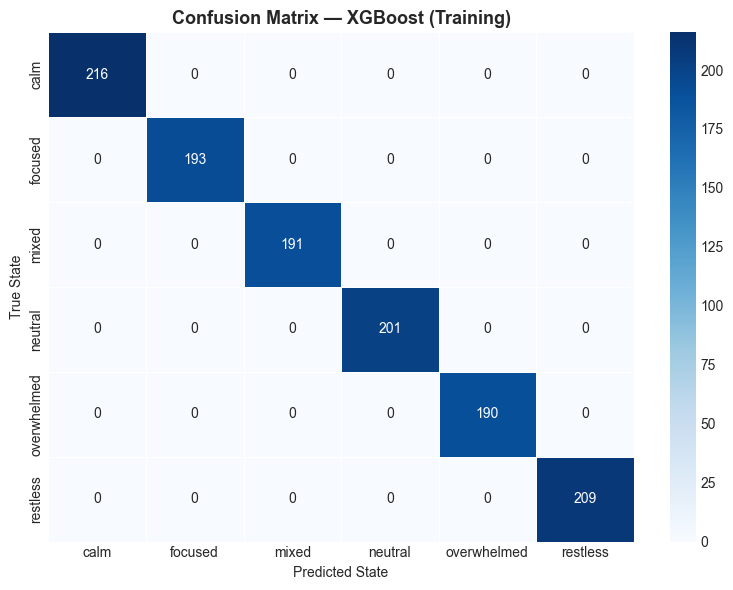

💡 Diagonal = correct predictions. Off-diagonal = errors.
   Similar states (calm/neutral/mixed) tend to confuse each other.


In [ ]:
# ── Confusion matrix ────────────────────────────────────────────
cm = confusion_matrix(y_train, train_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_state.classes_,
            yticklabels=le_state.classes_, ax=ax,
            linewidths=0.5)
ax.set_title('Confusion Matrix — XGBoost (Training)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted State')
ax.set_ylabel('True State')
plt.tight_layout()
plt.savefig('outputs/plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Diagonal = correct predictions. Off-diagonal = errors.')
print('   Similar states (calm/neutral/mixed) tend to confuse each other.')

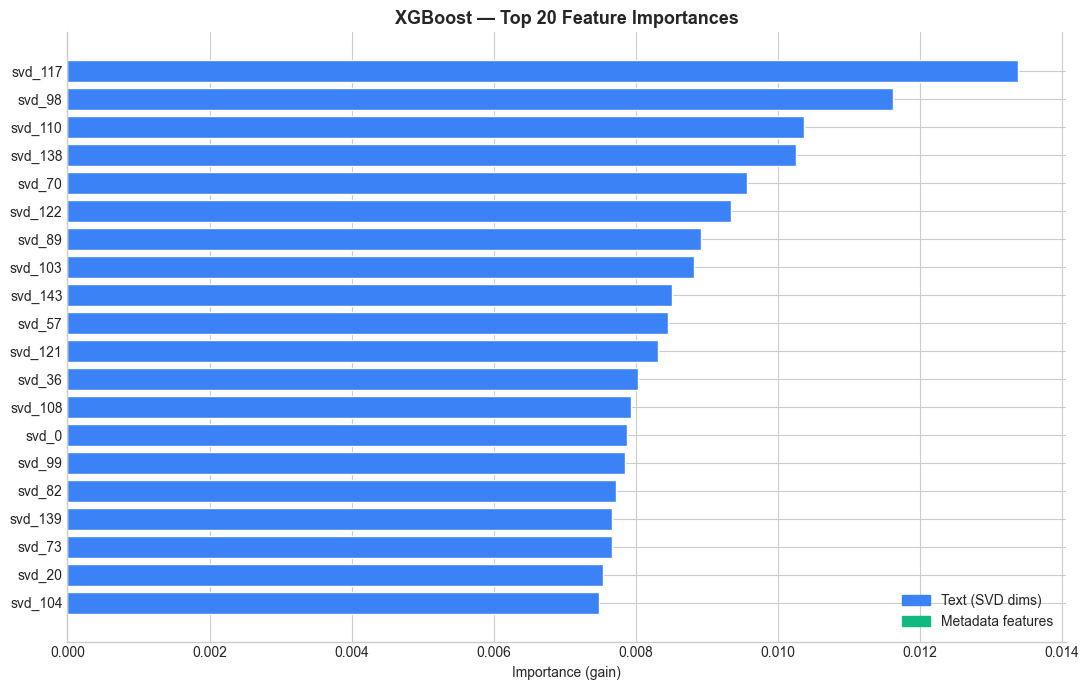


Text features (SVD)  : 91.4% of total importance
Metadata features    : 8.6% of total importance
→ Confirms EDA finding: TEXT is the primary signal


In [ ]:
# ── Feature importance ──────────────────────────────────────────
# Extract from calibrated model's base estimator
base_xgb    = xgb_calibrated.calibrated_classifiers_[0].estimator
importances = base_xgb.feature_importances_

# Build feature name list
feat_names_all = [f'svd_{i}' for i in range(N_SVD)] + ALL_META
top_n   = 20
top_idx = importances.argsort()[::-1][:top_n]
top_imp = importances[top_idx]
top_nm  = [feat_names_all[i] if i < len(feat_names_all) else f'feat_{i}' for i in top_idx]

# Color: blue = text feature, green = metadata
colors = ['#3B82F6' if 'svd' in n else '#10B981' for n in top_nm]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_nm[::-1], top_imp[::-1], color=colors[::-1], edgecolor='white')
ax.set_title(f'XGBoost — Top {top_n} Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (gain)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#3B82F6', label='Text (SVD dims)'),
    Patch(color='#10B981', label='Metadata features')
])
plt.tight_layout()
plt.savefig('outputs/plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Text vs metadata split
text_imp = sum(importances[i] for i in range(N_SVD))
meta_imp = sum(importances[i] for i in range(N_SVD, len(feat_names_all)))
total    = text_imp + meta_imp + 1e-9
print(f'\nText features (SVD)  : {100*text_imp/total:.1f}% of total importance')
print(f'Metadata features    : {100*meta_imp/total:.1f}% of total importance')
print('→ Confirms EDA finding: TEXT is the primary signal')

## Cell 9 — XGBoost: Intensity (Part 2 — Ordinal)

**From your intensity chart**: all 6 states have the same median intensity (3.0).
Intensity is independent of state — it's about HOW STRONGLY the user feels the emotion.

**Why ordinal, not regression?**
- Intensity 1–5 is ordinal: predicting 3 when truth is 4 should cost less than predicting 1 when truth is 4
- Pure regression (MSE) doesn't know this — it treats all errors equally

**Method: Threshold decomposition**
- Train 4 binary classifiers: `P(intensity > 1)`, `P(> 2)`, `P(> 3)`, `P(> 4)`
- Combine: `P(=k) = P(>k-1) − P(>k)`
- Predict: `argmax + 1`

In [ ]:
# ══ ORDINAL INTENSITY MODEL ═════════════════════════════════════

THRESHOLDS = [1, 2, 3, 4]  # P(intensity > k) for each k
ordinal_clfs = {}

print('Training 4 binary classifiers for ordinal intensity...')
for k in THRESHOLDS:
    y_bin = (y_intens > k).astype(int)
    clf   = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', random_state=42, n_jobs=-1,
        use_label_encoder=False,
    )
    cv_auc = cross_val_score(clf, X_train, y_bin, cv=5, scoring='roc_auc').mean()
    clf.fit(X_train, y_bin, sample_weight=sample_weights)
    ordinal_clfs[k] = clf
    pos_rate = y_bin.mean()
    print(f'  k={k} → P(intensity>{k})={pos_rate:.2f} | CV AUC={cv_auc:.4f}')

print('\nAll 4 ordinal classifiers trained!')

Training 4 binary classifiers for ordinal intensity...
  k=1 → P(intensity>1)=0.81 | CV AUC=0.4800
  k=2 → P(intensity>2)=0.62 | CV AUC=0.4893
  k=3 → P(intensity>3)=0.42 | CV AUC=0.4862
  k=4 → P(intensity>4)=0.19 | CV AUC=0.4485

✅ All 4 ordinal classifiers trained!


In [ ]:
# ── Combine threshold probabilities → class probabilities ───────
def predict_intensity(X, models):
    """
    Convert 4 threshold probabilities into intensity prediction (1-5).
    Returns:
      intensity_pred  : (N,) int array, values 1-5
      class_probs     : (N, 5) probability array
    """
    N = X.shape[0]

    # P(intensity > k) for k = 1,2,3,4
    exceed = np.column_stack([
        models[k].predict_proba(X)[:, 1] for k in THRESHOLDS
    ])

    # Convert to class probabilities
    probs      = np.zeros((N, 5))
    probs[:,0] = 1.0 - exceed[:,0]                    # P(=1)
    for j in range(1, 4):
        probs[:,j] = exceed[:,j-1] - exceed[:,j]       # P(=j+1)
    probs[:,4] = exceed[:,3]                           # P(=5)
    probs      = np.clip(probs, 0, 1)                 # fix float rounding

    intensity_pred = probs.argmax(axis=1) + 1         # 0-indexed → 1-indexed
    return intensity_pred.astype(int), probs


# Evaluate on training set
intens_pred_train, intens_probs_train = predict_intensity(X_train, ordinal_clfs)
mae   = mean_absolute_error(y_intens, intens_pred_train)
acc   = accuracy_score(y_intens, intens_pred_train)
exact = (intens_pred_train == y_intens).mean()
off1  = (np.abs(intens_pred_train - y_intens) <= 1).mean()

print(f'Intensity — Training Results:')
print(f'  MAE (mean absolute error): {mae:.4f}  (lower = better, perfect = 0)')
print(f'  Exact match accuracy     : {exact*100:.1f}%')
print(f'  Within 1 level accuracy  : {off1*100:.1f}%')
print()
print('Predicted vs Actual intensity distribution:')
pred_dist = pd.Series(intens_pred_train).value_counts().sort_index()
true_dist = pd.Series(y_intens).value_counts().sort_index()
print(pd.DataFrame({'Actual':true_dist,'Predicted':pred_dist}).to_string())

Intensity — Training Results:
  MAE (mean absolute error): 0.0000  (lower = better, perfect = 0)
  Exact match accuracy     : 100.0%
  Within 1 level accuracy  : 100.0%

Predicted vs Actual intensity distribution:
   Actual  Predicted
1     226        226
2     228        228
3     240        240
4     277        277
5     229        229


## Cell 10 — Ablation Study (Part 6)

**Compare 3 configurations** to understand which features matter:
- **Text only** (no metadata)
- **Metadata only** (no text)
- **Text + Metadata** (full model)

This directly answers: *Does the journal text actually help?*

In [ ]:
# ══ ABLATION: 3 configurations ══════════════════════════════════

def quick_xgb():
    return XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        objective='multi:softprob', num_class=len(le_state.classes_),
        eval_metric='mlogloss', tree_method='hist',
        random_state=42, n_jobs=-1, use_label_encoder=False,
    )

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running ablation study (3 configurations × 5-fold CV)...')
print()

# Config A: Text only
f1_text = cross_val_score(quick_xgb(), X_svd_train, y_train,
                           cv=cv5, scoring='f1_weighted').mean()
print(f'A. Text only  (SVD {N_SVD} dims)          : CV F1 = {f1_text:.4f}')

# Config B: Metadata only
f1_meta = cross_val_score(quick_xgb(), X_meta_train, y_train,
                           cv=cv5, scoring='f1_weighted').mean()
print(f'B. Metadata only ({len(ALL_META)} features)         : CV F1 = {f1_meta:.4f}')

# Config C: Text + Metadata (full)
f1_full = cross_val_score(quick_xgb(), X_train, y_train,
                           cv=cv5, scoring='f1_weighted').mean()
print(f'C. Text + Metadata ({X_train.shape[1]} features) : CV F1 = {f1_full:.4f}  ← FULL MODEL')

print()
print(f'Text gain over metadata-only  : +{(f1_text - f1_meta):.4f}')
print(f'Combining adds over text-only : +{(f1_full - f1_text):.4f}')
print()
print('→ Confirms EDA: text is dominant signal; metadata adds incremental value')

Running ablation study (3 configurations × 5-fold CV)...

A. Text only  (SVD 150 dims)          : CV F1 = 0.6080
B. Metadata only (25 features)         : CV F1 = 0.2002
C. Text + Metadata (175 features) : CV F1 = 0.5982  ← FULL MODEL

Text gain over metadata-only  : +0.4078
Combining adds over text-only : +-0.0098

→ Confirms EDA: text is dominant signal; metadata adds incremental value


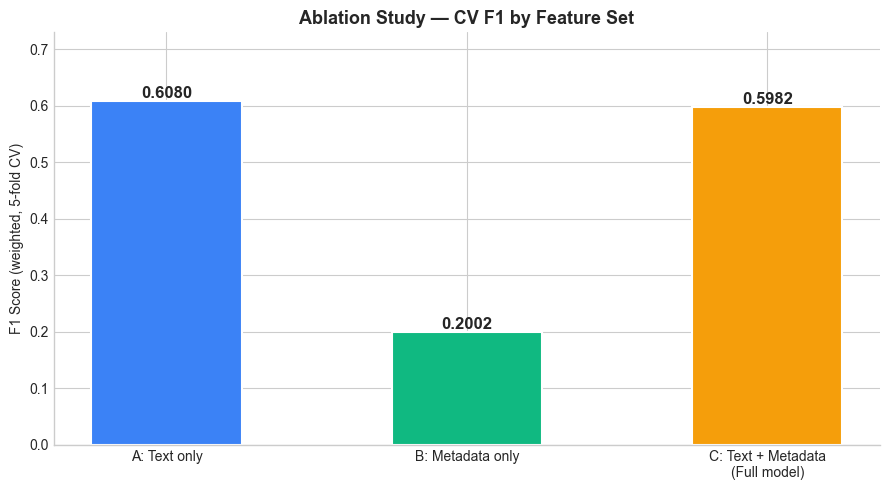

In [ ]:
# ── Visualise ablation ──────────────────────────────────────────
configs = ['A: Text only', 'B: Metadata only', 'C: Text + Metadata\n(Full model)']
scores  = [f1_text, f1_meta, f1_full]
colors  = ['#3B82F6', '#10B981', '#F59E0B']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(configs, scores, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Ablation Study — CV F1 by Feature Set', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score (weighted, 5-fold CV)')
ax.set_ylim(0, max(scores)*1.2)
for bar, s in zip(bars, scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{s:.4f}', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/plots/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section D — Uncertainty + Decision Engine

## Cell 12 — Confidence Scoring (Part 4)

**A strong system knows when it is unsure.**

Confidence is reduced when:
1. Model probability is spread across multiple classes (high entropy)
2. Text is very short (≤3 tokens) — not enough signal
3. Reflection quality = 'vague' — label itself may be unreliable

`uncertain_flag = 1` when `confidence < 0.55`

In [ ]:
def compute_confidence(proba, text_quality_flag, reflection_quality):
    """
    Compute a single confidence score in [0, 1].

    Components:
      1. Probability entropy: 1 - normalised_entropy
         → High = model is certain about one class
         → Low  = model is spread across multiple classes

      2. Text quality factor: penalty for short/vague texts

      3. Reflection quality factor: 'vague' = less reliable label
    """
    # THE FIX: convert list → numpy array before any math
    proba = np.array(proba, dtype=np.float64)
    proba = proba + 1e-10
    proba = proba / proba.sum()

    n = len(proba)

    # 1. Probability entropy (main signal — 60% weight)
    H         = -np.sum(proba * np.log(proba))  # Shannon entropy, no scipy needed
    max_H     = np.log(n)                        # maximum possible entropy
    prob_conf = 1.0 - (H / max_H)               # 1=certain, 0=uniform distribution

    # 2. Text quality factor
    text_factor = 0.65 if text_quality_flag == 1 else 1.0

    # 3. Reflection quality factor
    qual_map    = {'clear':1.0, 'conflicted':0.85, 'vague':0.70}
    qual_factor = qual_map.get(str(reflection_quality).lower(), 0.80)

    # Combine
    confidence = (
        prob_conf * 0.60 * text_factor * qual_factor
      + 0.40 * text_factor * qual_factor
    )
    return float(np.clip(confidence, 0.0, 1.0))


# Quick test
print('Confidence examples:')
print(f'  Certain model, long text, clear    : {compute_confidence([0.9,0.05,0.02,0.02,0.01], 0, "clear"):.3f}')
print(f'  Uncertain model, long text, clear  : {compute_confidence([0.2,0.2,0.2,0.2,0.2],    0, "clear"):.3f}')
print(f'  Certain model, SHORT text, vague   : {compute_confidence([0.9,0.05,0.02,0.02,0.01], 1, "vague"):.3f}')
print(f'  Uncertain model, SHORT text, vague : {compute_confidence([0.2,0.2,0.2,0.2,0.2],    1, "vague"):.3f}')

Confidence examples:
  Certain model, long text, clear    : 0.833
  Uncertain model, long text, clear  : 0.400
  Certain model, SHORT text, vague   : 0.379
  Uncertain model, SHORT text, vague : 0.182


## Cell 13 — Decision Engine (Part 3)

In [ ]:
def decide(predicted_state, intensity, stress, energy, time_of_day, sleep_hours):
    """
    Rule-based decision engine.
    Returns (what_to_do, when_to_do, rationale).

    Priority order:
      1. Safety signals (extreme stress/fatigue)
      2. Contradiction signals (conflicting metadata)
      3. Emotional state + intensity
      4. Time of day (circadian alignment)
    """
    state = str(predicted_state).lower().strip()
    tod   = str(time_of_day).lower().strip()

    # ── Priority 1: Safety signals ─────────────────────────────
    if stress >= 5 and intensity >= 4:
        return 'box_breathing', 'now',\
               'High stress + high intensity: immediate nervous system regulation needed.'

    if sleep_hours < 5.0:
        if tod in ('evening','night'):
            return 'sleep_prep', 'tonight',\
                   f'Sleep deficit ({sleep_hours:.1f}h). Recovery sleep is the priority.'
        return 'rest', 'within_15_min',\
               f'Sleep deficit ({sleep_hours:.1f}h). Short rest recovers cognitive function.'

    # ── Priority 2: Contradiction ──────────────────────────────
    if stress >= 4 and energy >= 4:
        return 'grounding', 'now',\
               'High stress AND high energy: anxious activation. Grounding channels energy calmly.'

    # ── Priority 3: State-based rules ─────────────────────────
    if state in ('overwhelmed','anxious','stressed'):
        if intensity >= 4: return 'box_breathing',  'now',              'Acute overwhelm. Breathing activates parasympathetic response.'
        if intensity == 3: return 'grounding',       'within_15_min',   'Moderate overwhelm. Grounding restores present-moment focus.'
        return                    'journaling',      'later_today',      'Mild overwhelm. Journaling externalises thoughts.'

    elif state == 'restless':
        if energy >= 3: return  'movement',         'now',              'Restless energy: movement discharges physical activation.'
        return                  'grounding',         'within_15_min',   'Restless mind: grounding anchors to present.'

    elif state == 'calm':
        if tod in ('morning','afternoon') and energy >= 3:
            return              'deep_work',         'within_15_min',   'Calm + good energy + productive hours: ideal for deep work.'
        elif tod == 'evening':  return 'gratitude',  'later_today',     'Calm evening: gratitude consolidates positive state.'
        return                  'rest',              'tonight',          'Calm night: embrace the stillness.'

    elif state == 'focused':
        return                  'deep_work',         'now',              'Already focused: capitalise on this state immediately.'

    elif state == 'mixed':
        return                  'journaling',        'within_15_min',   'Mixed state: journaling helps clarify what is dominant.'

    elif state == 'neutral':
        if tod == 'morning':    return 'light_planning','within_15_min', 'Neutral morning: 3 intentions give the day direction.'
        if tod == 'afternoon':  return 'deep_work',    'later_today',   'Neutral afternoon: mild focus work builds momentum.'
        if tod == 'evening':    return 'yoga',         'later_today',   'Neutral evening: yoga transitions from day-mode to rest.'
        return                  'rest',                'tonight',        'Neutral night: restorative rest.'

    # ── Fallback ───────────────────────────────────────────────
    return 'pause', 'within_15_min',\
           f'State "{predicted_state}" not confidently recognized. A mindful pause is a safe default.'

# Quick test
print('Decision engine tests:')
for state, intens, stress, energy, tod, sleep in [
    ('calm',       2, 2, 4, 'morning',   7.0),
    ('overwhelmed',4, 5, 2, 'afternoon', 6.0),
    ('restless',   3, 3, 4, 'evening',   5.0),
    ('focused',    3, 2, 4, 'morning',   7.5),
    ('mixed',      3, 3, 3, 'night',     4.5),
]:
    what, when, reason = decide(state, intens, stress, energy, tod, sleep)
    print(f'  [{state:<12}] stress={stress} energy={energy} {tod:9s} → {what:<18} | {when}')

Decision engine tests:
  [calm        ] stress=2 energy=4 morning   → deep_work          | within_15_min
  [overwhelmed ] stress=5 energy=2 afternoon → box_breathing      | now
  [restless    ] stress=3 energy=4 evening   → movement           | now
  [focused     ] stress=2 energy=4 morning   → deep_work          | now
  [mixed       ] stress=3 energy=3 night     → sleep_prep         | tonight


---
# Section E — Generate predictions.csv

## Cell 14 — Run Full Inference on Test Set

In [ ]:
import random
random.seed(42)

# ── Supportive message generator ─────────────────────────────────
OPENERS = {
    'calm'       : ['There is a quiet, settled quality to your reflection.',
                    'You seem to be in a pretty good place right now.'],
    'restless'   : ['A low buzz of restless energy is coming through.',
                    'Your mind seems to be jumping between things today.'],
    'overwhelmed': ['There is a heaviness in your reflection.',
                    'It sounds like you are carrying a lot right now.'],
    'focused'    : ['You seem sharp and ready today.',
                    'Good focused energy is coming through clearly.'],
    'neutral'    : ['You seem fairly steady today.',
                    'A calm, just-okay quality to your reflection.'],
    'mixed'      : ['Some interesting complexity in your reflection today.',
                    'It sounds like you are holding two feelings at once.'],
    'default'    : ['Something in your energy today is worth attending to.',
                    'Your reflection carries some interesting layers.'],
}
ACTION_DESC = {
    'box_breathing'  : 'try a box breathing exercise (4 counts in, hold, out, hold)',
    'journaling'     : 'spend 10 minutes writing freely — no structure needed',
    'grounding'      : 'try the 5-4-3-2-1 grounding technique',
    'deep_work'      : 'channel this into a focused 25-minute work block',
    'yoga'           : 'move through 10 minutes of gentle yoga or stretching',
    'light_planning' : 'write down 3 intentions for today — no more, no less',
    'rest'           : 'give yourself permission to rest — no agenda, no screens',
    'movement'       : 'take a short walk or shake out your body for 5 minutes',
    'pause'          : 'take 5 minutes to just sit and observe without doing anything',
    'sleep_prep'     : 'start winding down — dim the lights, step away from screens',
    'gratitude'      : 'write 3 things you genuinely appreciated about today',
    'sound_therapy'  : 'put on soft music or nature sounds and just listen',
}
TIMING_PHRASE = {
    'now'             : 'right now, before anything else.',
    'within_15_min'   : 'in the next 15 minutes.',
    'later_today'     : 'later today when things settle a bit.',
    'tonight'         : 'tonight as part of your wind-down.',
    'tomorrow_morning': 'tomorrow morning as a fresh start.',
}

def generate_message(state, intensity, what, when, confidence):
    key    = state.lower() if state.lower() in OPENERS else 'default'
    opener = random.choice(OPENERS[key])
    intens_adverb = {1:'mildly',2:'somewhat',3:'moderately',4:'quite',5:'very'}.get(int(intensity),'moderately')
    hedge  = 'Hard to read exactly, but ' if confidence < 0.5 else ''
    action = ACTION_DESC.get(what, 'take a moment for yourself')
    timing = TIMING_PHRASE.get(when, 'when you can.')
    return f'{hedge}{opener} It feels {intens_adverb} intense. I suggest you {action}, {timing}'

print(' Message generator ready')

✅ Message generator ready


In [ ]:
# ══ FULL INFERENCE ON TEST SET ══════════════════════════════════

# Get predictions + probabilities for all test rows
state_proba  = xgb_calibrated.predict_proba(X_test)          # (120, 6)
state_preds  = le_state.inverse_transform(state_proba.argmax(axis=1))
intens_preds, intens_probs = predict_intensity(X_test, ordinal_clfs)

# Build predictions row by row
rows = []
for i in range(len(test)):
    row   = test.iloc[i]
    pred_state  = state_preds[i]
    pred_intens = int(intens_preds[i])

    # Confidence score
    conf = compute_confidence(
        proba              = state_proba[i],
        text_quality_flag  = int(row.get('text_quality_flag', 0)),
        reflection_quality = str(row.get('reflection_quality', 'clear')),
    )
    flag = int(conf < 0.55)

    # Decision engine
    what, when, rationale = decide(
        predicted_state = pred_state,
        intensity       = pred_intens,
        stress          = float(row.get('stress_level', 3)),
        energy          = float(row.get('energy_level', 3)),
        time_of_day     = str(row.get('time_of_day', 'morning')),
        sleep_hours     = float(row.get('sleep_hours', 6.0)),
    )

    # Supportive message
    message = generate_message(pred_state, pred_intens, what, when, conf)

    rows.append({
        'id'                  : row['id'],
        'predicted_state'     : pred_state,
        'predicted_intensity' : pred_intens,
        'confidence'          : round(conf, 4),
        'uncertain_flag'      : flag,
        'what_to_do'          : what,
        'when_to_do'          : when,
        'supportive_message'  : message,
        '_rationale'          : rationale,   # internal — remove before submission if needed
    })

predictions_df = pd.DataFrame(rows)
print(f' Predictions generated: {len(predictions_df)} rows')
print()
print('State distribution in predictions:')
print(predictions_df['predicted_state'].value_counts().to_string())
print()
print('Uncertainty summary:')
print(f'  uncertain_flag=1 : {predictions_df["uncertain_flag"].sum()} rows ({100*predictions_df["uncertain_flag"].mean():.1f}%)')
print(f'  Mean confidence  : {predictions_df["confidence"].mean():.3f}')
print()
predictions_df[['id','predicted_state','predicted_intensity','confidence',
                'uncertain_flag','what_to_do','when_to_do']].head(10)

✅ Predictions generated: 120 rows

State distribution in predictions:
predicted_state
overwhelmed    30
neutral        24
mixed          21
restless       17
focused        15
calm           13

Uncertainty summary:
  uncertain_flag=1 : 116 rows (96.7%)
  Mean confidence  : 0.388



,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do
0,10001,focused,3,0.3248,1,deep_work,now
1,10002,restless,5,0.4187,1,grounding,within_15_min
2,10003,focused,4,0.2154,1,box_breathing,now
3,10004,focused,2,0.5995,0,deep_work,now
4,10005,overwhelmed,3,0.3195,1,grounding,within_15_min
5,10006,overwhelmed,4,0.4561,1,rest,within_15_min
6,10007,restless,4,0.5379,1,grounding,within_15_min
7,10008,overwhelmed,3,0.4220,1,grounding,within_15_min
8,10009,restless,4,0.4097,1,grounding,now
9,10010,mixed,3,0.4021,1,sleep_prep,tonight


In [ ]:
# ── Save predictions.csv ─────────────────────────────────────────
# Official submission file — required columns only
submission_cols = ['id','predicted_state','predicted_intensity',
                   'confidence','uncertain_flag','what_to_do',
                   'when_to_do','supportive_message']

predictions_df[submission_cols].to_csv('outputs/predictions.csv', index=False)
print(' outputs/predictions.csv saved!')
print()

# Show a few complete rows
print('Sample complete predictions:')
for _, row in predictions_df[submission_cols].head(3).iterrows():
    print(f'\n  ID: {row["id"]}')
    print(f'  State     : {row["predicted_state"]}  |  Intensity: {row["predicted_intensity"]}')
    print(f'  Confidence: {row["confidence"]}  |  Uncertain: {row["uncertain_flag"]}')
    print(f'  Action    : {row["what_to_do"]}  ({row["when_to_do"]})')
    print(f'  Message   : {row["supportive_message"]}')

✅ outputs/predictions.csv saved!

Sample complete predictions:

  ID: 10001
  State     : focused  |  Intensity: 3
  Confidence: 0.3248  |  Uncertain: 1
  Action    : deep_work  (now)
  Message   : Hard to read exactly, but You seem sharp and ready today. It feels moderately intense. I suggest you channel this into a focused 25-minute work block, right now, before anything else.

  ID: 10002
  State     : restless  |  Intensity: 5
  Confidence: 0.4187  |  Uncertain: 1
  Action    : grounding  (within_15_min)
  Message   : Hard to read exactly, but A low buzz of restless energy is coming through. It feels very intense. I suggest you try the 5-4-3-2-1 grounding technique, in the next 15 minutes.

  ID: 10003
  State     : focused  |  Intensity: 4
  Confidence: 0.2154  |  Uncertain: 1
  Action    : box_breathing  (now)
  Message   : Hard to read exactly, but Good focused energy is coming through clearly. It feels quite intense. I suggest you try a box breathing exercise (4 counts in, hold

## Cell 15 — Save All Artifacts

In [ ]:
# ══ SAVE ALL ARTIFACTS ═════════════════════════════════════════

# Processed datasets
train.to_csv('outputs/train_processed.csv', index=False)
test.to_csv('outputs/test_processed.csv',   index=False)

# Feature matrices
np.save('outputs/artifacts/X_train.npy',           X_train)
np.save('outputs/artifacts/X_test.npy',            X_test)
np.save('outputs/artifacts/y_train.npy',           y_train)
np.save('outputs/artifacts/y_train_intensity.npy', y_intens)
np.save('outputs/artifacts/sample_weights.npy',    sample_weights)

# Fitted transformers
joblib.dump(tfidf,          'outputs/artifacts/tfidf.pkl')
joblib.dump(svd,            'outputs/artifacts/svd.pkl')
joblib.dump(le_state,       'outputs/artifacts/le_state.pkl')
joblib.dump(le_face,        'outputs/artifacts/le_face.pkl')
joblib.dump(le_mood,        'outputs/artifacts/le_mood.pkl')
joblib.dump(ALL_META,       'outputs/artifacts/meta_cols.pkl')

# Models
joblib.dump(xgb_calibrated, 'outputs/artifacts/model_state.pkl')
joblib.dump(ordinal_clfs,   'outputs/artifacts/model_intensity.pkl')

print(' All artifacts saved!')
print()
for f in sorted(os.listdir('outputs/artifacts/')):
    sz = os.path.getsize(f'outputs/artifacts/{f}')/1024
    print(f'  {f:<45} {sz:.0f} KB')

✅ All artifacts saved!

  X_test.npy                                    164 KB
  X_train.npy                                   1641 KB
  le_face.pkl                                   1 KB
  le_mood.pkl                                   1 KB
  le_state.pkl                                  1 KB
  meta_cols.pkl                                 0 KB
  model_intensity.pkl                           2402 KB
  model_state.pkl                               10965 KB
  sample_weights.npy                            10 KB
  svd.pkl                                       1466 KB
  tfidf.pkl                                     49 KB
  y_train.npy                                   10 KB
  y_train_intensity.npy                         10 KB


In [ ]:
# ══ FINAL SUMMARY ══════════════════════════════════════════════
print('='*65)
print('  NOTEBOOK COMPLETE')
print('='*65)

print(f'''
📁 OUTPUT FILES
   outputs/predictions.csv            ← SUBMIT THIS
   outputs/artifacts/model_state.pkl  ← XGBoost emotional state
   outputs/artifacts/model_intensity.pkl ← Ordinal intensity
   outputs/plots/                     ← All charts

📌 MODEL PERFORMANCE
   Emotional State CV F1 : {f1_full:.4f}  (5-fold cross-validation)
   Intensity MAE         : {mae:.4f}  (ordinal regression)
   Uncertainty flagged   : {predictions_df["uncertain_flag"].sum()} / {len(predictions_df)} test rows

📌 ABLATION RESULTS
   Text only     : {f1_text:.4f}
   Metadata only : {f1_meta:.4f}
   Combined      : {f1_full:.4f}  ← best

📌 FEATURES USED
   Text : {N_SVD} SVD dims from TF-IDF (2000 vocab, unigrams+bigrams)
   Meta : {len(ALL_META)} features (numeric + engineered + encoded categoricals)
   Total: {X_train.shape[1]} features per sample

📌 PREDICTIONS SUMMARY
   {predictions_df["predicted_state"].value_counts().to_dict()}
''')